# EDA v2

**원천**: ChatGPT 분석에서 도출된 10개 프롬프트 (나이/이력/시술 유형/배아·난자/이식 전략/불임 원인/donor/결측/interaction/leakage)

각 § 셀이 하나의 프롬프트에 대응. 모든 분석은 **train 데이터만 사용**, test 데이터로는 schema 검증과 drift 점검만.

**Leakage 원칙**:
- target rate, target encoding, scaling, imputation 통계는 train fold 내부에서만
- test에는 transform/reindex만, fit 금지
- pd.get_dummies는 train 기준 컬럼으로 test reindex

In [34]:
from pathlib import Path
import sys; sys.path.insert(0, '..')
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 90
sns.set_palette('Set2')

TARGET = '임신 성공 여부'
DATA = Path('../data') if (Path('../data')).exists() else Path('data')
from pathlib import Path
DATA = Path('../data') if (Path('..')/'data').exists() else Path('data')
train = pd.read_csv(DATA/'train.csv')
test = pd.read_csv(DATA/'test.csv')
print(f'train: {train.shape}, test: {test.shape}')
print(f'positive rate: {train[TARGET].mean():.4%}')
age_order = ['만18-34세','만35-37세','만38-39세','만40-42세','만43-44세','만45-50세','알 수 없음']
count_order = ['0회','1회','2회','3회','4회','5회','6회 이상']
COUNT_INT = {c:i for i,c in enumerate(count_order)}

train: (256351, 69), test: (90067, 68)
positive rate: 25.8349%


## §1. 나이 효과 중심 EDA

**가설** (메타분석 2025 Hum Reprod): female age는 가장 강한 predictor 중 하나

               n  success_rate  n_pos
시술 당시 나이                             
만18-34세   102476        0.3226  33061
만35-37세    57780        0.2784  16086
만38-39세    39247        0.2171   8522
만40-42세    37348        0.1594   5953
만43-44세    12253        0.1180   1446
만45-50세     6918        0.1677   1160
알 수 없음       329        0.0000      0


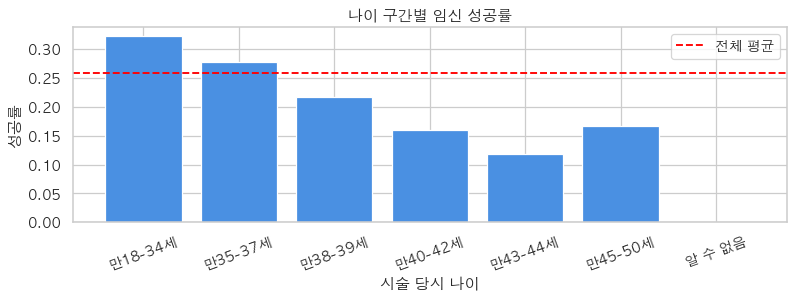

In [35]:
# §1. 나이 효과 중심 EDA

import platform
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# 한글 폰트 설정
if platform.system() == "Windows":
    font_name = "Malgun Gothic"
elif platform.system() == "Darwin":  # macOS
    font_name = "AppleGothic"
else:  # Linux / WSL
    font_name = "NanumGothic"

plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

sns.set_theme(
    style="whitegrid",
    font=font_name,
    rc={"axes.unicode_minus": False}
)
sns.set_palette("Set2")

# 1.1 시술 당시 나이 구간별 성공률 + 표본수
age_order = [
    "만18-34세",
    "만35-37세",
    "만38-39세",
    "만40-42세",
    "만43-44세",
    "만45-50세",
    "알 수 없음"
]

g = (
    train
    .groupby("시술 당시 나이")[TARGET]
    .agg(n="count", success_rate="mean")
    .reindex(age_order)
)

g["n_pos"] = (g["n"] * g["success_rate"]).astype(int)

print(g.round(4))

fig, ax = plt.subplots(figsize=(9, 3.5))

ax.bar(
    range(len(g)),
    g["success_rate"],
    color="#4a90e2"
)

ax.set_xticks(range(len(g)))
ax.set_xticklabels(g.index, rotation=20)

ax.axhline(
    train[TARGET].mean(),
    color="red",
    linestyle="--",
    label="전체 평균"
)

ax.set_title("나이 구간별 임신 성공률")
ax.set_ylabel("성공률")
ax.set_xlabel("시술 당시 나이")
ax.legend()

plt.tight_layout()
plt.show()

시술 유형        DI    IVF
시술 당시 나이              
만18-34세   0.195  0.325
만35-37세   0.151  0.282
만38-39세   0.103  0.220
만40-42세   0.069  0.162
만43-44세   0.019  0.122
만45-50세   0.004  0.174
알 수 없음      NaN  0.000


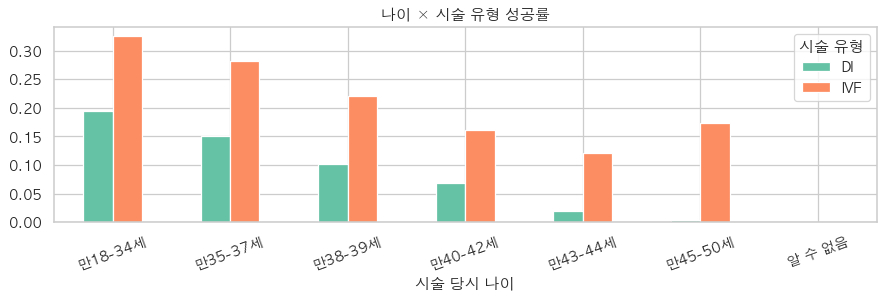

In [36]:
# 1.2 나이 × 시술 유형 (IVF / DI)
ix = train.groupby(['시술 당시 나이','시술 유형'])[TARGET].mean().unstack().reindex(age_order)
print(ix.round(3))
ix.plot.bar(figsize=(10,3.5), title='나이 × 시술 유형 성공률'); plt.xticks(rotation=20); plt.tight_layout(); plt.show()

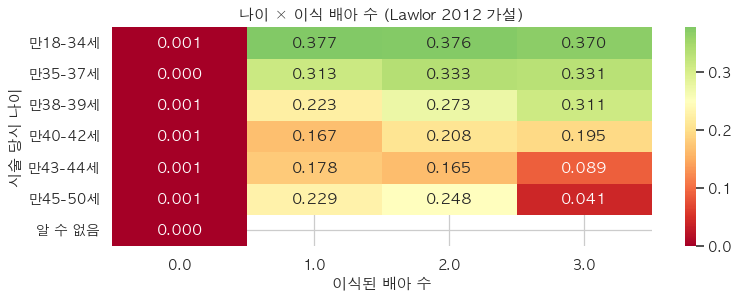

In [37]:
# 1.3 나이 × 이식된 배아 수
ivf = train[train['시술 유형']=='IVF']
ix = ivf.groupby(['시술 당시 나이','이식된 배아 수'])[TARGET].mean().unstack().reindex(age_order)
import seaborn as sns
fig, ax = plt.subplots(figsize=(9,3.5))
sns.heatmap(ix[[c for c in [0.0,1.0,2.0,3.0] if c in ix.columns]], annot=True, fmt='.3f', cmap='RdYlGn', center=0.25, ax=ax)
ax.set_title('나이 × 이식 배아 수 (Lawlor 2012 가설)'); plt.tight_layout(); plt.show()

In [38]:
# 1.4 나이 × 배아 이식 경과일 (day3 vs day5 proxy)
day_map = {2:'day0-2', 3:'day3', 4:'day3', 5:'day5+', 6:'day5+', 7:'day5+'}
ivf['_transfer_day_bin'] = ivf['배아 이식 경과일'].map(day_map).fillna('NA/cancelled')
ix = ivf.groupby(['시술 당시 나이','_transfer_day_bin'])[TARGET].mean().unstack().reindex(age_order)
print(ix.round(3))

_transfer_day_bin  NA/cancelled  day0-2   day3  day5+
시술 당시 나이                                             
만18-34세                   0.114   0.295  0.336  0.451
만35-37세                   0.131   0.235  0.293  0.404
만38-39세                   0.115   0.177  0.219  0.344
만40-42세                   0.094   0.126  0.158  0.281
만43-44세                   0.080   0.069  0.116  0.256
만45-50세                   0.103   0.086  0.173  0.361
알 수 없음                    0.000     NaN    NaN    NaN


In [39]:
# 1.5 donor age × 본인 age
donor_only = train[train['난자 출처']=='기증 제공']
if len(donor_only) > 100:
    print('기증 난자 사용 그룹 (n={})'.format(len(donor_only)))
    print('난자 기증자 나이별 성공률:')
    print(donor_only.groupby('난자 기증자 나이')[TARGET].agg(['mean','count']).round(4))
    ix = donor_only.groupby(['시술 당시 나이','난자 기증자 나이'])[TARGET].mean().unstack()
    print('\n시술 당시 나이 × 난자 기증자 나이:')
    print(ix.round(3))

기증 난자 사용 그룹 (n=15769)
난자 기증자 나이별 성공률:
             mean  count
난자 기증자 나이               
만20세 이하    0.2619    294
만21-25세    0.3299   2334
만26-30세    0.3483   4976
만31-35세    0.3052   6366
알 수 없음     0.2507   1799

시술 당시 나이 × 난자 기증자 나이:
난자 기증자 나이  만20세 이하  만21-25세  만26-30세  만31-35세  알 수 없음
시술 당시 나이                                             
만18-34세      0.286    0.317    0.345    0.297   0.247
만35-37세      0.161    0.350    0.342    0.310   0.288
만38-39세      0.188    0.336    0.361    0.329   0.244
만40-42세      0.328    0.339    0.354    0.323   0.227
만43-44세      0.304    0.362    0.370    0.329   0.237
만45-50세      0.244    0.301    0.328    0.268   0.265


**§1 후보 파생변수**: `age_ord`, `age_mid`, `age_35p`, `age_38p`, `age_43p`, `age_unknown`, age × 시술 유형, age × 이식된 배아 수, age × 배아 이식 경과일, age × 난자 출처

## §2. 과거 시술·임신·출산 이력 EDA

**가설** (McLernon model): 과거 이력은 prognosis를 반영

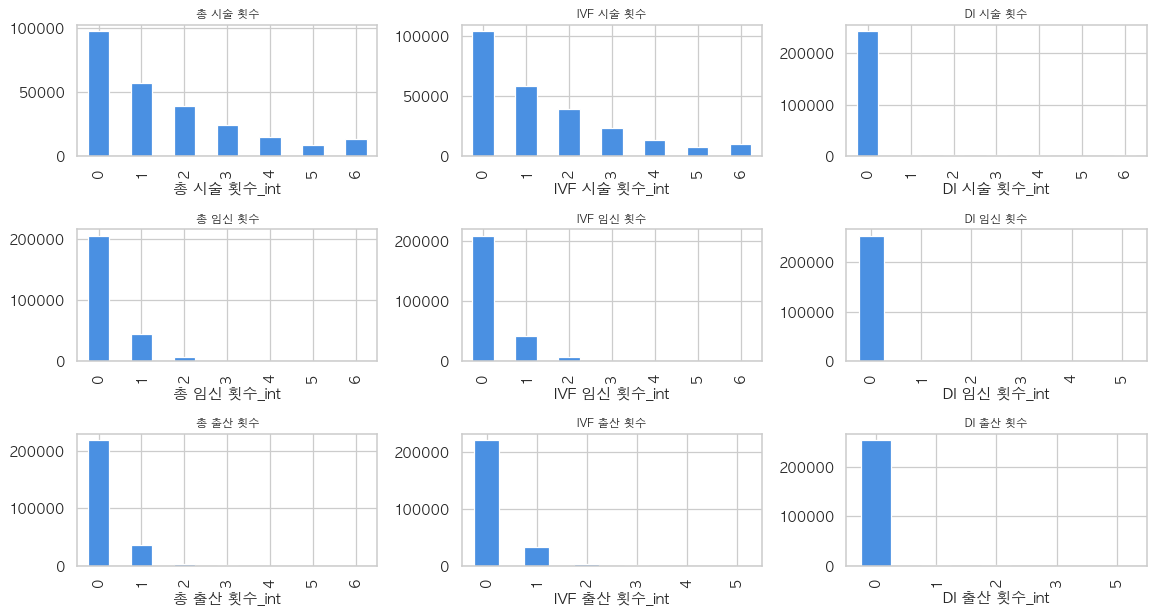

In [40]:
# 2.1 횟수 컬럼 → 정수 변환 + 분포
count_cols = ['총 시술 횟수','IVF 시술 횟수','DI 시술 횟수',
              '총 임신 횟수','IVF 임신 횟수','DI 임신 횟수',
              '총 출산 횟수','IVF 출산 횟수','DI 출산 횟수']
for c in count_cols:
    if c in train.columns:
        train[c+'_int'] = train[c].map(COUNT_INT).fillna(-1)
fig, axes = plt.subplots(3, 3, figsize=(13,7))
for ax, c in zip(axes.flat, count_cols):
    if c+'_int' in train.columns:
        train[c+'_int'].value_counts().sort_index().plot.bar(ax=ax, color='#4a90e2')
        ax.set_title(c, fontsize=9)
plt.tight_layout(); plt.show()

In [41]:
# 2.2 과거 임신 있음/없음, 과거 출산 있음/없음
train['_prior_pregnancy_any'] = (train['총 임신 횟수_int'] >= 1).astype(int)
train['_prior_live_birth_any'] = (train['총 출산 횟수_int'] >= 1).astype(int)
train['_prior_pregnancy_no_birth'] = ((train['총 임신 횟수_int'] >= 1) & (train['총 출산 횟수_int']==0)).astype(int)
for c in ['_prior_pregnancy_any','_prior_live_birth_any','_prior_pregnancy_no_birth']:
    print(f'{c}: n={train[c].sum()}, LBR={train[train[c]==1][TARGET].mean():.4f} vs no={train[train[c]==0][TARGET].mean():.4f}')

_prior_pregnancy_any: n=50925, LBR=0.2620 vs no=0.2575
_prior_live_birth_any: n=37796, LBR=0.2670 vs no=0.2569
_prior_pregnancy_no_birth: n=13129, LBR=0.2474 vs no=0.2589


In [42]:
# 2.3 ratio: prior_live_birth / prior_treatment
for num_col, den_col, name in [
    ('총 출산 횟수_int','총 시술 횟수_int','live_birth_per_treatment'),
    ('총 임신 횟수_int','총 시술 횟수_int','pregnancy_per_treatment'),
    ('IVF 임신 횟수_int','IVF 시술 횟수_int','ivf_preg_per_ivf_tr'),
]:
    if num_col in train and den_col in train:
        ratio = train[num_col] / train[den_col].replace(0, np.nan)
        train['_'+name] = ratio.fillna(-1).clip(-1, 2)
        print(f'{name}: corr with target = {train["_"+name].corr(train[TARGET]):.4f}')

live_birth_per_treatment: corr with target = -0.0434
pregnancy_per_treatment: corr with target = -0.0409
ivf_preg_per_ivf_tr: corr with target = -0.0352


**§2 후보 파생**: `count_int` (모든 횟수), `prior_pregnancy_any`, `prior_live_birth_any`, `prior_pregnancy_no_live_birth`, `live_birth_per_treatment`, `pregnancy_per_treatment`, IVF/DI별 ratio

## §3. 시술 유형·특정 시술 텍스트 파싱 EDA

**가설**: '특정 시술 유형'에 ICSI/IVF/IUI/BLASTOCYST/AH/FER/Unknown 등이 혼재

In [43]:
# 3.1 시술 유형별 성공률
print(train.groupby('시술 유형')[TARGET].agg(['count','mean']).round(4))
print()
# 특정 시술 유형 top 카테고리
vc = train['특정 시술 유형'].value_counts().head(15)
rate = train.groupby('특정 시술 유형')[TARGET].mean()
top_df = pd.DataFrame({'count':vc, 'success_rate':rate.loc[vc.index]}).round(4)
print('Top 15 특정 시술 유형:'); print(top_df)

        count    mean
시술 유형                
DI       6291  0.1289
IVF    250060  0.2616

Top 15 특정 시술 유형:
                     count  success_rate
특정 시술 유형                                
ICSI                122368        0.2728
IVF                  91755        0.2615
Unknown              26939        0.2372
IUI                   6100        0.1285
ICSI:ICSI             2314        0.0099
ICSI / BLASTOCYST     1609        0.3567
IVF / BLASTOCYST      1248        0.3662
IVF:IVF               1146        0.0105
ICSI:IVF               873        0.2348
ICSI / AH              769        0.2172
IVF:ICSI               392        0.2832
IVF / AH               319        0.1850
ICSI:Unknown           207        0.1014
IVF:Unknown            100        0.1700
ICI                     96        0.1354


In [44]:
# 3.2 token 포함 여부 plug-and-play
tokens = ['ICSI','IVF','IUI','BLASTOCYST','AH','FER','UNKNOWN','Unknown','알 수 없음']
rows = []
for t in tokens:
    mask = train['특정 시술 유형'].fillna('').str.upper().str.contains(t.upper(), regex=False)
    if mask.sum() > 0:
        rows.append({'token':t, 'n':int(mask.sum()), 'lbr_with':train[mask][TARGET].mean(),
                     'lbr_without':train[~mask][TARGET].mean()})
tok_df = pd.DataFrame(rows)
tok_df['delta'] = (tok_df['lbr_with']-tok_df['lbr_without']).round(4)
print(tok_df.round(4))

        token       n  lbr_with  lbr_without   delta
0        ICSI  128547    0.2683       0.2483  0.0200
1         IVF   95845    0.2593       0.2578  0.0015
2         IUI    6100    0.1285       0.2615 -0.1330
3  BLASTOCYST    2868    0.3609       0.2572  0.1037
4          AH    1092    0.2079       0.2586 -0.0507
5         FER       3    0.3333       0.2583  0.0750
6     UNKNOWN   27248    0.2359       0.2610 -0.0251
7     Unknown   27248    0.2359       0.2610 -0.0251


In [45]:
# 3.3 token 개수
def count_tokens(s):
    if pd.isna(s): return 0
    return sum([1 for t in tokens if t.upper() in s.upper()])
train['_token_count'] = train['특정 시술 유형'].apply(count_tokens)
print(train.groupby('_token_count')[TARGET].agg(['count','mean']).round(4))

               count    mean
_token_count                
0                194  0.1392
1             223686  0.2602
2              32150  0.2477
3                319  0.1285
4                  2  0.5000


**§3 후보 파생**: `treat_has_icsi`, `treat_has_ivf`, `treat_has_iui`, `treat_has_blastocyst`, `treat_has_ah`, `treat_has_fer`, `treat_has_unknown`, `treat_token_count`

## §4. 배아·난자 수치 feature EDA

**가설** (Zou 2025 RF AUC 0.808): retrieved oocyte / usable embryo / endometrial thickness가 핵심.
본 데이터의 proxy: 총 생성 배아 수, 이식된 배아 수, 혼합된 난자 수, 미세주입된 난자 수

In [46]:
num_cols = ['총 생성 배아 수','미세주입된 난자 수','미세주입에서 생성된 배아 수',
            '이식된 배아 수','미세주입 배아 이식 수','저장된 배아 수','미세주입 후 저장된 배아 수',
            '해동된 배아 수','해동 난자 수','수집된 신선 난자 수','저장된 신선 난자 수',
            '혼합된 난자 수','파트너 정자와 혼합된 난자 수','기증자 정자와 혼합된 난자 수']
rows = []
for c in num_cols:
    if c not in train: continue
    s = train[c]
    rows.append({'col':c, 'na%':round(s.isna().mean()*100,1),
                 'zero%':round((s==0).mean()*100,1),
                 'mean':round(s.mean(),2), 'median':round(s.median(),2),
                 'p99':round(s.quantile(0.99),0), 'max':round(s.max(),0)})
print(pd.DataFrame(rows).to_string(index=False))

             col  na%  zero%  mean  median  p99  max
       총 생성 배아 수  2.5   20.8  5.06     4.0 20.0 51.0
      미세주입된 난자 수  2.5   49.8  4.17     0.0 22.0 51.0
 미세주입에서 생성된 배아 수  2.5   51.4  2.84     0.0 17.0 43.0
        이식된 배아 수  2.5   14.3  1.37     1.0  3.0  3.0
    미세주입 배아 이식 수  2.5   54.1  0.72     0.0  3.0  3.0
        저장된 배아 수  2.5   65.1  1.19     0.0 12.0 51.0
 미세주입 후 저장된 배아 수  2.5   79.7  0.61     0.0  9.0 51.0
        해동된 배아 수  2.5   81.8  0.45     0.0  7.0 32.0
         해동 난자 수  2.5   97.0  0.05     0.0  0.0 36.0
     수집된 신선 난자 수  2.5   21.0  8.56     8.0 30.0 51.0
     저장된 신선 난자 수  2.5   96.5  0.09     0.0  2.0 51.0
        혼합된 난자 수  2.5   18.2  7.70     7.0 27.0 51.0
파트너 정자와 혼합된 난자 수  2.5   24.5  7.11     6.0 27.0 51.0
기증자 정자와 혼합된 난자 수  2.5   91.5  0.53     0.0 14.0 50.0


In [47]:
# 4.1 효율 ratio 계산 + target association
ivf2 = train[train['시술 유형']=='IVF'].copy()
ivf2['_생성_per_난자'] = ivf2['총 생성 배아 수'] / ivf2['혼합된 난자 수'].replace(0,np.nan)
ivf2['_이식_per_생성'] = ivf2['이식된 배아 수'] / ivf2['총 생성 배아 수'].replace(0,np.nan)
ivf2['_저장_per_생성'] = ivf2['저장된 배아 수'] / ivf2['총 생성 배아 수'].replace(0,np.nan)
ivf2['_미세주입_효율'] = ivf2['미세주입에서 생성된 배아 수'] / ivf2['미세주입된 난자 수'].replace(0,np.nan)
for c in ['_생성_per_난자','_이식_per_생성','_저장_per_생성','_미세주입_효율']:
    s = ivf2[c].dropna()
    print(f'{c}: median={s.median():.3f}, corr w/ target = {ivf2[c].corr(ivf2[TARGET]):.4f}')

_생성_per_난자: median=0.692, corr w/ target = 0.1136
_이식_per_생성: median=0.250, corr w/ target = -0.0926
_저장_per_생성: median=0.000, corr w/ target = 0.0009
_미세주입_효율: median=0.714, corr w/ target = 0.1190


In [48]:
# 4.2 quantile bin별 성공률 (총 생성 배아 수)
for c in ['총 생성 배아 수','이식된 배아 수','수집된 신선 난자 수']:
    if c not in train: continue
    bins = train[c].quantile([0,0.2,0.4,0.6,0.8,1.0]).unique()
    if len(bins) >= 3:
        train[c+'_bin'] = pd.cut(train[c], bins=bins, include_lowest=True, duplicates='drop')
        print(f'{c}:')
        print(train.groupby(c+'_bin', observed=True)[TARGET].agg(['count','mean']).round(4)); print()

총 생성 배아 수:
                count    mean
총 생성 배아 수_bin                
(-0.001, 3.0]  108714  0.1760
(3.0, 5.0]      42022  0.2910
(5.0, 9.0]      59403  0.3392
(9.0, 51.0]     39921  0.3483

이식된 배아 수:
                count    mean
이식된 배아 수_bin                 
(-0.001, 1.0]  130335  0.2259
(1.0, 2.0]     110845  0.3111
(2.0, 3.0]       8880  0.1685

수집된 신선 난자 수:
                  count    mean
수집된 신선 난자 수_bin                
(-0.001, 6.0]    107423  0.2038
(6.0, 10.0]       52115  0.2778
(10.0, 14.0]      41832  0.3274
(14.0, 51.0]      48690  0.3152



**§4 후보 파생**: `log1p_*` (모든 수치), `is_zero_*`, `is_missing_*`, `생성_per_난자`, `이식_per_생성`, `저장_per_생성`, `미세주입_효율`, `생성_minus_이식`, `생성_minus_이식저장`

## §5. 배아 이식 전략 EDA

**가설** (Sci Reports validated model): age × stage × fresh/frozen × N_transfer interaction이 핵심.
live birth per embryo: 35세 fresh blastocyst 43% → 43세 frozen cleavage 1%

In [49]:
# 5.1 이식된 배아 수별
print('이식 배아 수별 성공률:')
print(train.groupby('이식된 배아 수')[TARGET].agg(['count','mean']).round(4))
print()
# 5.2 단일 배아 이식 여부
if '단일 배아 이식 여부' in train:
    print('단일 배아 이식 여부별:')
    print(train.groupby('단일 배아 이식 여부')[TARGET].agg(['count','mean']).round(4))

이식 배아 수별 성공률:
           count    mean
이식된 배아 수                
0.0        36544  0.0008
1.0        93791  0.3135
2.0       110845  0.3111
3.0         8880  0.1685

단일 배아 이식 여부별:
              count    mean
단일 배아 이식 여부                
0.0          191677  0.2294
1.0           58383  0.3672


In [50]:
# 5.3 배아 이식 경과일 day grouping
def day_bin(d):
    if pd.isna(d): return 'cancelled/NA'
    if d <= 2: return 'day0-2'
    if d == 3: return 'day3'
    if d == 4: return 'day4'
    if d == 5: return 'day5'
    return 'day6+'
train['_transfer_day_bin'] = train['배아 이식 경과일'].apply(day_bin)
print(train.groupby('_transfer_day_bin')[TARGET].agg(['count','mean']).round(4))

                   count    mean
_transfer_day_bin               
cancelled/NA       43566  0.0238
day0-2             66035  0.2247
day3               57924  0.2588
day4                4504  0.3444
day5               81459  0.4044
day6+               2863  0.3035


In [51]:
# 5.4 fresh / frozen / donor pattern
for c in ['신선 배아 사용 여부','동결 배아 사용 여부','기증 배아 사용 여부']:
    if c in train:
        print(f'{c}:'); print(train.groupby(c)[TARGET].agg(['count','mean']).round(4)); print()
# 5.5 fresh × frozen pattern
if all(c in train.columns for c in ['신선 배아 사용 여부','동결 배아 사용 여부']):
    train['_fresh_frozen_pattern'] = (train['신선 배아 사용 여부'].fillna(-1).astype(str) + '_' +
                                     train['동결 배아 사용 여부'].fillna(-1).astype(str))
    print(train.groupby('_fresh_frozen_pattern')[TARGET].agg(['count','mean']).round(4))

신선 배아 사용 여부:
              count    mean
신선 배아 사용 여부                
0.0           39924  0.2296
1.0          210136  0.2677

동결 배아 사용 여부:
              count    mean
동결 배아 사용 여부                
0.0          209934  0.2678
1.0           40126  0.2294

기증 배아 사용 여부:
              count    mean
기증 배아 사용 여부                
0.0          247602  0.2610
1.0            2458  0.3275

                        count    mean
_fresh_frozen_pattern                
-1.0_-1.0                6291  0.1289
0.0_0.0                     3  0.3333
0.0_1.0                 39921  0.2296
1.0_0.0                209931  0.2678
1.0_1.0                   205  0.1951


**§5 후보 파생**: `has_embryo_transfer` (=배아 이식 경과일 not NA), `transfer_day_bin`, `transfer_day3`/`day5`, `fresh_frozen_pattern`, `age_x_transfer_bin`, `transfer_day_x_transfer_count`, `blastocyst_x_transfer_day` (token AND day=5)

## §6. 불임 원인 EDA

**가설**: 단일 원인보다 **원인 조합** 분석이 효과적. 남성/여성/부부/불명확 stratification.

In [52]:
cause_cols = [c for c in train.columns if '불임 원인' in c]
print(f'불임 원인 컬럼 {len(cause_cols)}개')
rows = []
for c in cause_cols:
    n_pos = (train[c]==1).sum()
    if n_pos > 0:
        lbr_y = train[train[c]==1][TARGET].mean()
        lbr_n = train[train[c]!=1][TARGET].mean()
        rows.append({'cause':c, 'n':int(n_pos), 'lbr_yes':round(lbr_y,4),
                     'lbr_no':round(lbr_n,4), 'delta':round(lbr_y-lbr_n,4)})
df_cause = pd.DataFrame(rows).sort_values('delta',key=abs, ascending=False)
print(df_cause.head(20).to_string(index=False))

불임 원인 컬럼 17개
             cause     n  lbr_yes  lbr_no   delta
   불임 원인 - 자궁경부 문제    10   0.0000  0.2584 -0.2584
불임 원인 - 정자 면역학적 요인     1   0.0000  0.2583 -0.2583
    불임 원인 - 정자 운동성    97   0.1753  0.2584 -0.0831
        부부 부 불임 원인  2247   0.1869  0.2590 -0.0721
        여성 부 불임 원인  3187   0.1958  0.2591 -0.0633
        남성 부 불임 원인  3362   0.1975  0.2592 -0.0617
        여성 주 불임 원인  7876   0.2191  0.2596 -0.0404
        남성 주 불임 원인  7310   0.2200  0.2595 -0.0395
        부부 주 불임 원인  8477   0.2202  0.2597 -0.0394
     불임 원인 - 정자 형태   143   0.2238  0.2584 -0.0346
     불임 원인 - 남성 요인 95466   0.2799  0.2456  0.0343
     불임 원인 - 배란 장애 33426   0.2866  0.2541  0.0325
     불임 원인 - 정자 농도   276   0.2500  0.2584 -0.0084
     불임 원인 - 자궁내막증 18302   0.2548  0.2586 -0.0038
         불명확 불임 원인 64275   0.2595  0.2580  0.0015
     불임 원인 - 난관 질환 35557   0.2578  0.2584 -0.0007


In [53]:
# cause aggregates
binary_cause = [c for c in cause_cols if (train[c].dropna().isin([0,1])).all() and (train[c]==1).sum()>0]
train['_cause_total'] = train[binary_cause].sum(axis=1)
print('원인 개수별 성공률:')
print(train.groupby('_cause_total')[TARGET].agg(['count','mean']).round(4))

원인 개수별 성공률:
               count    mean
_cause_total                
0              44310  0.2047
1             169046  0.2717
2              30033  0.2780
3               2750  0.2476
4               8654  0.2147
5               1371  0.2188
6                137  0.1898
7                 43  0.2326
8                  7  0.0000


In [54]:
# 남성/여성/부부 분리 카운트
male_cause = [c for c in binary_cause if any(k in c for k in ['남성','정자'])]
female_cause = [c for c in binary_cause if any(k in c for k in ['여성','난관','자궁','배란'])]
couple_cause = [c for c in binary_cause if '부부' in c]
train['_cause_male_count'] = train[male_cause].sum(axis=1)
train['_cause_female_count'] = train[female_cause].sum(axis=1)
train['_cause_couple_count'] = train[couple_cause].sum(axis=1)
train['_cause_male_any'] = (train['_cause_male_count']>0).astype(int)
train['_cause_female_any'] = (train['_cause_female_count']>0).astype(int)
train['_cause_male_female_both'] = ((train['_cause_male_any']==1)&(train['_cause_female_any']==1)).astype(int)
print(f'남성+여성 동시: n={train["_cause_male_female_both"].sum()}, LBR={train[train["_cause_male_female_both"]==1][TARGET].mean():.4f}')
print(f'원인 없음: n={(train["_cause_total"]==0).sum()}, LBR={train[train["_cause_total"]==0][TARGET].mean():.4f}')

남성+여성 동시: n=30553, LBR=0.2584
원인 없음: n=44310, LBR=0.2047


**§6 후보 파생**: `cause_total`, `cause_any`, `cause_none`, `cause_multi`, `cause_male_count`, `cause_female_count`, `cause_male_any`, `cause_female_any`, `cause_male_female_both`, `unexplained_or_none`

## §7. 난자/정자 출처 + donor age EDA

In [55]:
# 7.1 난자 출처 × 정자 출처 cross
ix = train.groupby(['난자 출처','정자 출처'])[TARGET].agg(['count','mean']).round(4)
print(ix.sort_values('count', ascending=False).head(10))

                     count    mean
난자 출처  정자 출처                      
본인 제공  배우자 제공       216812  0.2570
       기증 제공         17357  0.2718
기증 제공  배우자 제공        12387  0.3161
알 수 없음 기증 제공          6291  0.1289
기증 제공  기증 제공          3368  0.3135
본인 제공  미할당             108  0.1019
기증 제공  미할당              14  0.1429
본인 제공  배우자 및 기증 제공      14  0.0000


In [56]:
# 7.2 donor age (난자)
donor = train[train['난자 출처']=='기증 제공']
if len(donor) > 0:
    print('기증 난자 사용 그룹 (n={}) 의 난자 기증자 나이별 LBR:'.format(len(donor)))
    print(donor.groupby('난자 기증자 나이')[TARGET].agg(['count','mean']).round(4))
# 7.3 donor age (정자)
sperm_donor = train[train['정자 출처']=='기증 제공']
if len(sperm_donor) > 0:
    print('\n기증 정자 사용 그룹의 정자 기증자 나이별 LBR:')
    print(sperm_donor.groupby('정자 기증자 나이')[TARGET].agg(['count','mean']).round(4))

기증 난자 사용 그룹 (n=15769) 의 난자 기증자 나이별 LBR:
           count    mean
난자 기증자 나이               
만20세 이하      294  0.2619
만21-25세     2334  0.3299
만26-30세     4976  0.3483
만31-35세     6366  0.3052
알 수 없음      1799  0.2507

기증 정자 사용 그룹의 정자 기증자 나이별 LBR:
           count    mean
정자 기증자 나이               
만20세 이하     1062  0.2090
만21-25세     5586  0.2413
만26-30세     4986  0.2473
만31-35세     4842  0.2480
만36-40세     5208  0.2450
만41-45세     3798  0.2414
알 수 없음      1534  0.2529


**§7 후보 파생**: `egg_source`, `sperm_source`, `egg_sperm_source_cross`, `egg_donor_age_ord`, `sperm_donor_age_ord`, `egg_donor_age_unknown`, `sperm_donor_age_unknown`, age_x_egg_source

## §8. 결측치 자체를 신호로

**가설**: '해당 단계 미진행' / '해당 시술 미적용'을 의미할 수 있음

In [57]:
rows = []
for c in train.columns:
    if c == TARGET: continue
    n_na = train[c].isna().sum()
    if 100 <= n_na < len(train)*0.99:
        lbr_na = train.loc[train[c].isna(), TARGET].mean()
        lbr_nn = train.loc[train[c].notna(), TARGET].mean()
        delta = lbr_na - lbr_nn
        if abs(delta) >= 0.01:
            rows.append({'col':c, 'n_na':int(n_na),
                         'lbr_na':round(float(lbr_na),4), 'lbr_nn':round(float(lbr_nn),4),
                         'delta':round(float(delta),4)})
df_na = pd.DataFrame(rows).sort_values('delta', key=abs, ascending=False)
print(df_na.head(15).to_string(index=False))

             col  n_na  lbr_na  lbr_nn   delta
       배아 이식 경과일 43566  0.0238  0.3064 -0.2826
     저장된 신선 난자 수  6291  0.1289  0.2616 -0.1327
     수집된 신선 난자 수  6291  0.1289  0.2616 -0.1327
    이식된 배아 수_bin  6291  0.1289  0.2616 -0.1327
   총 생성 배아 수_bin  6291  0.1289  0.2616 -0.1327
          대리모 여부  6291  0.1289  0.2616 -0.1327
     기증 배아 사용 여부  6291  0.1289  0.2616 -0.1327
     신선 배아 사용 여부  6291  0.1289  0.2616 -0.1327
     동결 배아 사용 여부  6291  0.1289  0.2616 -0.1327
기증자 정자와 혼합된 난자 수  6291  0.1289  0.2616 -0.1327
파트너 정자와 혼합된 난자 수  6291  0.1289  0.2616 -0.1327
        혼합된 난자 수  6291  0.1289  0.2616 -0.1327
     단일 배아 이식 여부  6291  0.1289  0.2616 -0.1327
 수집된 신선 난자 수_bin  6291  0.1289  0.2616 -0.1327
         해동 난자 수  6291  0.1289  0.2616 -0.1327


In [58]:
# 행 단위 missing count
train['_row_missing_count'] = train.isna().sum(axis=1)
bins = train['_row_missing_count'].quantile([0,0.25,0.5,0.75,0.9,1.0]).values
train['_row_missing_bin'] = pd.cut(train['_row_missing_count'], bins=np.unique(bins), include_lowest=True)
print(train.groupby('_row_missing_bin', observed=True)[TARGET].agg(['count','mean']).round(4))

                   count    mean
_row_missing_bin                
(2.999, 6.0]      174250  0.3084
(6.0, 7.0]         65025  0.1770
(7.0, 33.0]        17076  0.0577


**§8 후보 파생**: `{col}_isna` (informative한 컬럼만), `row_num_missing_count`, `cancelled_cycle` (배아 이식 경과일 isna)

## §9. Train-only Interaction Discovery

In [59]:
# 우선순위 interaction 10개
interactions = [
    ('시술 당시 나이', '특정 시술 유형'),
    ('시술 당시 나이', '이식된 배아 수'),
    ('시술 당시 나이', '_transfer_day_bin'),
    ('시술 당시 나이', '난자 출처'),
    ('특정 시술 유형', '배아 생성 주요 이유'),
    ('배아 생성 주요 이유', '이식된 배아 수'),
    ('신선 배아 사용 여부', '동결 배아 사용 여부'),
    ('난자 출처', '정자 출처'),
    ('총 시술 횟수', '_prior_live_birth_any'),
]
for c1, c2 in interactions:
    if c1 in train.columns and c2 in train.columns:
        ix = train.groupby([c1,c2])[TARGET].agg(['count','mean']).round(4)
        ix = ix[ix['count']>=100]
        if len(ix) > 0:
            print(f'\n=== {c1} × {c2} (top 10 by count, n>=100) ===')
            print(ix.sort_values('count', ascending=False).head(10))


=== 시술 당시 나이 × 특정 시술 유형 (top 10 by count, n>=100) ===
                   count    mean
시술 당시 나이 특정 시술 유형               
만18-34세  ICSI      52401  0.3407
         IVF       35273  0.3300
만35-37세  ICSI      27185  0.2892
         IVF       21013  0.2867
만38-39세  ICSI      18080  0.2231
만40-42세  ICSI      16791  0.1561
만38-39세  IVF       14377  0.2191
만40-42세  IVF       13773  0.1605
만18-34세  Unknown    8643  0.2683
만35-37세  Unknown    6282  0.2541

=== 시술 당시 나이 × 이식된 배아 수 (top 10 by count, n>=100) ===
                   count    mean
시술 당시 나이 이식된 배아 수               
만18-34세  1.0       46415  0.3772
         2.0       40214  0.3756
만35-37세  2.0       26987  0.3333
         1.0       21852  0.3126
만38-39세  2.0       21383  0.2730
만40-42세  2.0       15725  0.2083
만18-34세  0.0       13684  0.0010
만38-39세  1.0       11221  0.2225
만40-42세  1.0        8738  0.1665
만35-37세  0.0        7373  0.0004

=== 시술 당시 나이 × _transfer_day_bin (top 10 by count, n>=100) ===
                            count 

## §10. Leakage Audit

**점검**: train→test의 모든 통계 산출 위치, OOF 적용, post-outcome 변수

In [60]:
from src.validation.leakage_check import check_all
result = check_all(str(DATA/'train.csv'), str(DATA/'test.csv'))
import json; print(json.dumps(result, ensure_ascii=False, indent=2))

{
  "id_check": {
    "suspicious_id_cols": [
      "ID"
    ]
  },
  "future_leak_in_test": [],
  "only_train": [],
  "only_test": [],
  "columns_aligned": true,
  "class_balance": {
    "positive_rate": 0.2583489044318142,
    "n_pos": 66228,
    "n_neg": 190123
  },
  "period_overlap": {
    "train_only": [],
    "test_only": [],
    "shared": 7,
    "drift_warning": false
  },
  "n_train": 256351,
  "n_test": 90067
}


In [61]:
# train과 test 컬럼 일치 확인
tr_cols = set(train.columns) - {TARGET}
te_cols = set(test.columns)
print(f'only in train: {sorted(tr_cols - te_cols)}')
print(f'only in test:  {sorted(te_cols - tr_cols)}')
print('==> 둘 다 빈 list여야 함 (target만 train에 있음)')

only in train: ['DI 시술 횟수_int', 'DI 임신 횟수_int', 'DI 출산 횟수_int', 'IVF 시술 횟수_int', 'IVF 임신 횟수_int', 'IVF 출산 횟수_int', '_cause_couple_count', '_cause_female_any', '_cause_female_count', '_cause_male_any', '_cause_male_count', '_cause_male_female_both', '_cause_total', '_fresh_frozen_pattern', '_ivf_preg_per_ivf_tr', '_live_birth_per_treatment', '_pregnancy_per_treatment', '_prior_live_birth_any', '_prior_pregnancy_any', '_prior_pregnancy_no_birth', '_row_missing_bin', '_row_missing_count', '_token_count', '_transfer_day_bin', '수집된 신선 난자 수_bin', '이식된 배아 수_bin', '총 생성 배아 수_bin', '총 시술 횟수_int', '총 임신 횟수_int', '총 출산 횟수_int']
only in test:  []
==> 둘 다 빈 list여야 함 (target만 train에 있음)


In [63]:
# Post-outcome 의심 변수 점검
import pandas as pd
from pandas.api.types import is_numeric_dtype

post_outcome_keywords = ["임신", "출산", "live birth", "outcome", "결과"]

suspect = [
    c for c in train.columns
    if any(k.lower() in str(c).lower() for k in post_outcome_keywords)
    and c != TARGET
]

print("Post-outcome 의심 컬럼:")

for c in suspect:
    s = train[c]
    
    if is_numeric_dtype(s):
        summary = f"mean={s.mean():.4f}, missing={s.isna().mean():.2%}"
    else:
        nunique = s.nunique(dropna=True)
        top_values = s.value_counts(dropna=False).head(3).to_dict()
        summary = f"category/string, unique={nunique}, top={top_values}"
    
    print(f"  {c} ({summary})")

print("\n주의: 위 컬럼들은 cycle 이전(prior) 통계로 명확히 정의된 경우만 사용 가능")
print("총 임신 횟수, 총 출산 횟수 = 본 cycle 이전 누적 → OK (사용 가능)")

Post-outcome 의심 컬럼:
  임신 시도 또는 마지막 임신 경과 연수 (mean=9.2707, missing=96.34%)
  총 임신 횟수 (category/string, unique=7, top={'0회': 205426, '1회': 43829, '2회': 6246})
  IVF 임신 횟수 (category/string, unique=7, top={'0회': 208292, '1회': 41519, '2회': 5788})
  DI 임신 횟수 (category/string, unique=6, top={'0회': 253302, '1회': 2625, '2회': 368})
  총 출산 횟수 (category/string, unique=7, top={'0회': 218555, '1회': 35369, '2회': 2242})
  IVF 출산 횟수 (category/string, unique=6, top={'0회': 220831, '1회': 33348, '2회': 2021})
  DI 출산 횟수 (category/string, unique=5, top={'0회': 254009, '1회': 2138, '2회': 183})
  총 임신 횟수_int (mean=0.2301, missing=0.00%)
  IVF 임신 횟수_int (mean=0.2163, missing=0.00%)
  DI 임신 횟수_int (mean=0.0138, missing=0.00%)
  총 출산 횟수_int (mean=0.1577, missing=0.00%)
  IVF 출산 횟수_int (mean=0.1477, missing=0.00%)
  DI 출산 횟수_int (mean=0.0100, missing=0.00%)

주의: 위 컬럼들은 cycle 이전(prior) 통계로 명확히 정의된 경우만 사용 가능
총 임신 횟수, 총 출산 횟수 = 본 cycle 이전 누적 → OK (사용 가능)


---
## 종합 권장: §1~§10 발견을 반영한 학습 파이프라인

1. 모든 횟수 변수: ordinal 정수 + censored flag
2. 시술 유형 token 7개: `treat_has_*`
3. 배아·난자 효율 ratio 4개
4. fresh × frozen × donor pattern
5. 불임 원인 집계 (총/남/여/부부)
6. donor age ordinal
7. informative NaN flag
8. age × {시술 유형, transfer_day, transfer_count, donor} interaction

→ `src/features/v2_features.py` 모듈로 통합 (다음 셀)